# Embedding Data Processing and Feature Ranking
This pipeline converts complex geospatial raster data into structured, quantitative tables, effectively streamlining the transition from raw imagery to statistical analysis. The process begins by flattening multi-band spatial data (Z-score data) into a consolidated format, which is then synchronized with categorical class labels to ensure pixel-level alignment. Following this, the pipeline computes fundamental descriptive statistics including count, mean, and variance for each spectral band within every class. The final phase utilizes the Cohen’s $d$ statistic to evaluate the pairwise separability of distributions across all classes, resulting in a ranked feature list that highlights the most discriminative spectral components for classification.

### Imports

In [1]:
import rasterio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import os

In [2]:
import xarray as xr

ds2000 = xr.open_dataset("ESACCI-...-2000-...nc")
ds2020 = xr.open_dataset("C3S-...-2020-...nc")

lat_slice = slice(45.558, 45.485)  # often north-to-south; flip if it comes back empty
lon_slice = slice(9.042, 9.154)

milan_2000 = ds2000['lccs_class'].sel(lat=lat_slice, lon=lon_slice)
milan_2020 = ds2020['lccs_class'].sel(lat=lat_slice, lon=lon_slice)

milan_2000.rio.write_crs("EPSG:4326", inplace=True).rio.to_raster("milan_2000.tif")
milan_2020.rio.write_crs("EPSG:4326", inplace=True).rio.to_raster("milan_2020.tif")

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\user\\projects\\lc_intercomparison\\lc_accuracy\\ESACCI-...-2000-...nc'

### STEP 2a - TESSERA Embedding Raster (Z-Scores) to Tabular  array
Convert a standardized embedding raster (e.g., TESSERA embedding) into tabular (.csv and .dat) formats for processing. It is designed to facilitate large-scale statistical analysis by flattening high-dimensional 3D raster data into 2D matrices where each row represents a unique pixel and each column represents a spectral band.

#### Methodology
The conversion process performs the following operations:
1. **Raster Ingestion:** Opens the source file using `rasterio` and retrieves band count metadata.
2. **Data Flattening:** Reshapes the 3D data array `(Bands, Height, Width)` into a 2D table `(Pixels, Bands)`.
3. **Band Labeling:** Automatically assigns column headers (e.g., `Band_1`, `Band_2`) based on the input band count.
4. **Dual-Format Export:** Saves the results in two formats simultaneously:
   - `.csv`: Comma-separated values for standard Python data analysis.
   - `.dat`: Tab-separated values for compatibility with specific GIS and statistical software.

In [2]:
def raster_to_tabular_dual_output(input_path, base_output_path):
    """
    Processes the multispectral raster and saves it as both .csv and .dat.
    Headers are formatted as 'Band_1', 'Band_2', etc.
    """
    print(f"Opening raster: {os.path.basename(input_path)}...")
    
    with rasterio.open(input_path) as src:
        data = src.read()
        num_bands = src.count
        
        # Flattening 3D array to 2D (Pixels, Bands)
        flattened_data = data.reshape(num_bands, -1).T
        
        # Updated header logic: Band_1, Band_2, ... Band_n
        columns = [f'Band_{i+1}' for i in range(num_bands)]
        
        print(f"Processing {flattened_data.shape[0]} pixels...")
        df = pd.DataFrame(flattened_data, columns=columns)
        
        # Extract directory and base filename for export
        dir_name = os.path.dirname(base_output_path)
        file_name_no_ext = os.path.splitext(os.path.basename(base_output_path))[0]
        
        csv_path = os.path.join(dir_name, f"{file_name_no_ext}.csv")
        dat_path = os.path.join(dir_name, f"{file_name_no_ext}.dat")

        # Save CSV (Comma-separated)
        df.to_csv(csv_path, index=False)
        
        # Save DAT (Tab-separated)
        df.to_csv(dat_path, sep='\t', index=False)
            
    # --- VISIBLE OUTPUT IN CONSOLE ---
    print("-" * 30)
    print(f"Success! Files saved in: {dir_name}")
    print(f"Outputs: {os.path.basename(csv_path)} and {os.path.basename(dat_path)}")
    print("\nPreview of X (.dat):")
    # Display the first few rows with the new Band headers
    print(df.head(5).to_string())
    print("-" * 60)

# --- DATA SOURCE AND OUTPUT DIRECTORY ---
input_raster = r"C:\Users\user\OneDrive - Politecnico di Milano\File di Daniele Oxoli - test_embeddings\Tessera2018clip_Zscore.tif"
output_base = r"C:\Users\user\OneDrive - Politecnico di Milano\File di Daniele Oxoli - test_embeddings\outputs\Z.dat" 

# Execute the script
raster_to_tabular_dual_output(input_raster, output_base)

# --- EXPECTED CONSOLE OUTPUT ---
# Opening raster: tess_2018_milan_clip.tif...
# Processing 703500 pixels...
# ------------------------------
# Success! Files saved in: C:\Users\user\OneDrive - Politecnico di Milano\00LCZ\geo_tessera
# Outputs: tess_Z.csv and tess_Z.dat
#
# Preview of X (.dat):
#      Band_1    Band_2    Band_3    Band_4    Band_5    Band_6 ...
# 0  3.180536 -1.445697 -0.289138  2.385393 -0.650563 -3.614237 ...
# ------------------------------------------------------------

Opening raster: Tessera2018clip_Zscore.tif...
Processing 703500 pixels...
------------------------------
Success! Files saved in: C:\Users\user\OneDrive - Politecnico di Milano\File di Daniele Oxoli - test_embeddings\outputs
Outputs: Z.csv and Z.dat

Preview of X (.dat):
     Band_1    Band_2    Band_3    Band_4    Band_5    Band_6    Band_7    Band_8    Band_9   Band_10   Band_11   Band_12   Band_13   Band_14   Band_15   Band_16   Band_17   Band_18   Band_19   Band_20   Band_21   Band_22   Band_23   Band_24   Band_25   Band_26   Band_27   Band_28   Band_29   Band_30   Band_31   Band_32   Band_33   Band_34   Band_35   Band_36   Band_37   Band_38   Band_39   Band_40   Band_41   Band_42   Band_43   Band_44   Band_45   Band_46   Band_47   Band_48   Band_49   Band_50   Band_51   Band_52   Band_53   Band_54   Band_55   Band_56   Band_57   Band_58   Band_59   Band_60   Band_61   Band_62   Band_63   Band_64   Band_65   Band_66   Band_67   Band_68   Band_69   Band_70   Band_71   Band_72   Band

### STEP 2b - IMD (Impervious Surface Density) Raster to Tabular Array
Extract the Impervious Surface Density (IMD Classes) into a structured array that matches the spatial extent of the spectral data. 
#### Methodology
The conversion follows these steps:
1. **Raster Ingestion:** Opens the `.tif` file using `rasterio`.
2. **Flattening:** Reshapes the 3D data array (Bands, Height, Width) into a 2D matrix (Pixels, Bands).
3. **Data Export:** Saves the output in two formats:
   - **.csv:** Comma-separated for general analysis.
   - **.dat:** Tab-separated for compatibility with GIS and statistical software.

In [3]:
def raster_to_tabular_dual_output(input_path, base_output_path):
    """
    Processes the multispectral raster and saves it as both .csv and .dat.
    The header is explicitly set to 'Class'.
    """
    print(f"Opening raster: {os.path.basename(input_path)}...")
    
    with rasterio.open(input_path) as src:
        data = src.read()
        num_bands = src.count
        
        # Flattening 3D array to 2D (Pixels, Bands)
        flattened_data = data.reshape(num_bands, -1).T
        
        # MODIFIED LOGIC: Use 'Class' instead of 'Band_1'
        # If the file has 1 band, name it 'Class'. 
        # If it has multiple, name the first 'Class' and the rest 'Band_X'
        if num_bands == 1:
            columns = ['Class']
        else:
            columns = ['Class'] + [f'Band_{i}' for i in range(2, num_bands + 1)]
        
        print(f"Processing {flattened_data.shape[0]} pixels...")
        df = pd.DataFrame(flattened_data, columns=columns)
        
        # Extract directory and base filename for export
        dir_name = os.path.dirname(base_output_path)
        file_name_no_ext = os.path.splitext(os.path.basename(base_output_path))[0]
        
        csv_path = os.path.join(dir_name, f"{file_name_no_ext}.csv")
        dat_path = os.path.join(dir_name, f"{file_name_no_ext}.dat")

        # Save CSV (Comma-separated)
        df.to_csv(csv_path, index=False)
        
        # Save DAT (Tab-separated)
        df.to_csv(dat_path, sep='\t', index=False)
            
    # --- VISIBLE OUTPUT IN CONSOLE ---
    print("-" * 30)
    print(f"Success! Files saved in: {dir_name}")
    print(f"Outputs: {os.path.basename(csv_path)} and {os.path.basename(dat_path)}")
    print("\nPreview of Y (.dat):")
    print(df.head(5).to_string())
    print("-" * 60)

# --- EXECUTION ---
input_raster = r"C:\Users\user\OneDrive - Politecnico di Milano\File di Daniele Oxoli - test_embeddings\imd_class_sample_no_coreg.tif"
output_base = r"C:\Users\user\OneDrive - Politecnico di Milano\File di Daniele Oxoli - test_embeddings\outputs\Y.dat" 

raster_to_tabular_dual_output(input_raster, output_base)
# --- EXPECTED CONSOLE OUTPUT ---
# Opening raster: imd_class_sample_no_coreg.tif...
# Processing 703500 pixels...
# ------------------------------
# Success! Files saved in: C:\Users\user\OneDrive - Politecnico di Milano\File di Daniele Oxoli - test_embeddings\outputs
# Outputs: imd_array1.csv and imd_array1.dat
# Preview of Y (.dat):
#Class 
#0     0.0
#1     5.0
#2     5.0
#3     5.0
#4     5.0


Opening raster: imd_class_sample_no_coreg.tif...
Processing 703500 pixels...
------------------------------
Success! Files saved in: C:\Users\user\OneDrive - Politecnico di Milano\File di Daniele Oxoli - test_embeddings\outputs
Outputs: Y.csv and Y.dat

Preview of Y (.dat):
   Class
0    0.0
1    5.0
2    5.0
3    5.0
4    5.0
------------------------------------------------------------


### STEP 3a - Statistical Aggregation
To condense high-dimensional spectral data into a representative summary table (Mean, Variance, and Pixel Count). By grouping pixels based on their class assignments and calculating descriptive statistics for each spectral band, we create a compact dataset that characterizes the distribution of each class.

##### 1. Count ($n$)
The total number of samples (pixels) assigned to a specific class:
$$n = \text{total number of pixels in class}$$

##### 2. Mean ($\mu$)
The arithmetic average of the pixel values for a given band within the class:
$$\mu = \frac{1}{n} \sum_{i=1}^{n} x_i$$

##### 3. Variance ($\sigma^2$)
The measure of dispersion, representing the spread of pixel values around the mean:
$$\sigma^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \mu)^2$$


In [4]:
# --- 1. LOAD THE DATA ---
tessera_path = r"C:\Users\user\OneDrive - Politecnico di Milano\File di Daniele Oxoli - test_embeddings\outputs\Z.dat"
imd_path = r"C:\Users\user\OneDrive - Politecnico di Milano\File di Daniele Oxoli - test_embeddings\outputs\Y.dat"

print("Loading files...")
df_tessera = pd.read_csv(tessera_path, sep='\t')
df_imd = pd.read_csv(imd_path, sep='\t')

# --- 2. PREPARE THE DATA ---
df_combined = df_tessera.copy()
df_combined['Class'] = df_imd.iloc[:, 0] 

print("Calculating Mean, Variance, and Count per Class...")

# --- 3. AGGREGATE ---
# Calculate mean, variance, and count
stats = df_combined.groupby('Class').agg(['mean', 'var', 'count'])

# --- 4. RESHAPE TO BANDS AS ROWS ---
# This results in MultiIndex columns: (Statistic, Class)
final_df = stats.stack(level=0).unstack(level=0)

# --- 5. REORDER COLUMNS (Count -> Mean -> Var) ---
# We iterate through unique classes to enforce the specific order: count, mean, var
unique_classes = sorted(df_combined['Class'].unique())
ordered_columns = []
for cls in unique_classes:
    ordered_columns.extend([('count', cls), ('mean', cls), ('var', cls)])

# Reindex dataframe to enforce the order
final_df = final_df[ordered_columns]

# Rename columns to: count_1, mean_1, var_1...
final_df.columns = [f"{stat}_{int(cls)}" for stat, cls in final_df.columns]

# --- 6. SAVE THE OUTPUT IN DUAL FORMATS ---
output_dir = r"C:\Users\user\OneDrive - Politecnico di Milano\File di Daniele Oxoli - test_embeddings\outputs"
base_name = "summary_stats_tab"

csv_path = os.path.join(output_dir, f"{base_name}.csv")
dat_path = os.path.join(output_dir, f"{base_name}.dat")

# Save as CSV (Comma-separated)
final_df.to_csv(csv_path)

# Save as DAT (Tab-separated)
final_df.to_csv(dat_path, sep='\t')

print("-" * 30)
print(f"Analysis Complete! Matrix size: {final_df.shape}")
print(f"CSV saved to: {csv_path}")
print(f"DAT saved to: {dat_path}")

# --- VISIBLE PREVIEW ---
print("\nPreview of Stats (Order: count, mean, var per Class):")
# Show first 3 classes to verify order
cols_to_preview = [c for c in final_df.columns if any(x in c for x in ['_1', '_2', '_3'])]
print(final_df[cols_to_preview].head(5).to_string())
print("-" * 60)

# --- EXPECTED CONSOLE OUTPUT ---
# Loading files...
# Calculating Mean, Variance, and Count per Class...
# ------------------------------
# Analysis Complete! Matrix size: (128, 54)
# CSV saved to: C:\Users\user\OneDrive - Politecnico di Milano\00LCZ\geo_tessera\band_full_stats_by_class_var.csv
# DAT saved to: C:\Users\user\OneDrive - Politecnico di Milano\00LCZ\geo_tessera\band_full_stats_by_class_var.dat
#
# Preview of Stats (Rows=Bands, Cols=Mean/Var/Count per Class):
#           count_1    mean_1     var_1   count_2    mean_2     var_2
# Band_1   15420.0   3.180536  0.204429   8450.0   0.452131  0.015497
# Band_2   15420.0  -1.445697  1.264398   8450.0   1.124512  0.307896
# Band_3   15420.0  -0.289138  0.787369   8450.0   0.887412  1.004296
# ------------------------------------------------------------

Loading files...
Calculating Mean, Variance, and Count per Class...
------------------------------
Analysis Complete! Matrix size: (128, 18)
CSV saved to: C:\Users\user\OneDrive - Politecnico di Milano\File di Daniele Oxoli - test_embeddings\outputs\summary_stats_tab.csv
DAT saved to: C:\Users\user\OneDrive - Politecnico di Milano\File di Daniele Oxoli - test_embeddings\outputs\summary_stats_tab.dat

Preview of Stats (Order: count, mean, var per Class):
        count_1    mean_1     var_1  count_2    mean_2     var_2  count_3    mean_3     var_3
Band_1    21698  0.680921  0.987789    67490  0.572819  0.866393    86070  0.420464  0.748907
Band_2    21698  0.185544  0.898442    67490  0.110560  0.814081    86070  0.132425  0.752279
Band_3    21698 -0.207134  0.892349    67490 -0.080309  0.892795    86070 -0.016468  0.952576
Band_4    21698 -0.310394  0.810850    67490 -0.437305  0.781340    86070 -0.473237  0.781501
Band_5    21698  0.413207  0.544640    67490  0.192476  0.564358    8607

### STEP 3b. Pairwise Cohen’s d Analysis for Spectral Components
To quantify the separability of each spectral component (band) across different IMD classes. By calculating the Cohen’s $d$ statistic for all pairwise combinations of classes, we can rank components based on their ability to consistently distinguish between class distributions.
#### Mathematical Methodology
For each component $j$ and every pair of classes $(k_1, k_2)$, the Cohen's $d$ statistic is computed as follows:
1. Pooled Standard DeviationFirst, we calculate the pooled standard deviation ($\sigma_{j,k_1,k_2}$) to account for the variance and sample size of both classes:$$\sigma_{j,k_1,k_2} = \sqrt{\frac{(n_{j,k_1}-1)\sigma^2_{j,k_1} + (n_{j,k_2}-1)\sigma^2_{j,k_2}}{n_{j,k_1} + n_{j,k_2} - 2}}$$
2. Cohen's $d$ StatisticNext, we calculate the standardized difference between the means of the two distributions:$$d_{j,k_1,k_2} = \frac{\mu_{j,k_1} - \mu_{j,k_2}}{\sigma_{j,k_1,k_2}}$$
3. Component Ranking ScoreFinally, we compute the median of the absolute Cohen's $d$ values across all class combinations to determine the component's overall discriminative power:$$\text{med\_}d_j = \text{median}(|d_{j,k_0,k_1}|, |d_{j,k_0,k_2}|, \dots, |d_{j,k_4,k_5}|)$$

#### Procedure
1. Data Preparation: Load the summary statistics (mean, variance, and count) generated in step 3 (above process).

2. Pairwise Generation: Generate all unique class combinations $(k_1, k_2)$ for 6 classes, this results in 15 specific pairs.

3. Pooled Calculation: Iteratively calculate the pooled standard deviation for every band per class pair.

4. Effect Size Computation: Calculate Cohen's $d$ for each pair and transform it into its absolute value to focus on the magnitude of the difference.

5. Median Aggregation: For each band, identify the median of the 15 calculated absolute Cohen's $d$ values.

6. Ranking: Sort the resulting table by the median score in descending order (highest score = best performing band).

In [5]:
# --- 1. LOAD THE DATA ---
input_file = r"C:\Users\user\OneDrive - Politecnico di Milano\File di Daniele Oxoli - test_embeddings\outputs\summary_stats_tab.csv"
df_stats = pd.read_csv(input_file, index_col=0) # Reads Band_X as index

# Define classes (Assuming 0 to 5 for 6 classes)
classes = range(6)
class_pairs = list(combinations(classes, 2))

# --- 2. CALCULATE COHEN'S D ---
results = []

for band, row in df_stats.iterrows():
    d_values = []
    
    for k1, k2 in class_pairs:
        # Extract stats for class k1
        n1 = row[f'count_{k1}']
        mu1 = row[f'mean_{k1}']
        var1 = row[f'var_{k1}']
        
        # Extract stats for class k2
        n2 = row[f'count_{k2}']
        mu2 = row[f'mean_{k2}']
        var2 = row[f'var_{k2}']
        
        # Calculate pooled standard deviation (sigma_j,k1,k2)
        # Formula: sqrt( ((n1-1)*var1 + (n2-1)*var2) / (n1 + n2 - 2) )
        numerator = ((n1 - 1) * var1) + ((n2 - 1) * var2)
        denominator = n1 + n2 - 2
        
        if denominator > 0:
            pooled_std = np.sqrt(numerator / denominator)
        else:
            pooled_std = 0
            
        # Calculate Cohen's d
        if pooled_std != 0:
            d = (mu1 - mu2) / pooled_std
        else:
            d = 0
            
        d_values.append(abs(d))
    
    # Calculate median of absolute values for this band
    med_d = np.median(d_values)
    results.append({'Band': band, 'med_d': med_d})

# --- 3. CREATE FINAL TABLE AND RANK ---
df_ranking = pd.DataFrame(results).set_index('Band')

# Sort from highest to lowest
df_ranking = df_ranking.sort_values(by='med_d', ascending=False)

# --- 4. SAVE AND PREVIEW ---
output_path = r"C:\Users\user\OneDrive - Politecnico di Milano\File di Daniele Oxoli - test_embeddings\outputs\component_ranking_cohen_d.csv"
df_ranking.to_csv(output_path)

print("-" * 30)
print(f"Complete! Ranking saved to: {output_path}")
print("\nPreview of Top 10 Ranked Components (Highest med_d first):")
print(df_ranking.head(10).to_string())
print("-" * 60)

------------------------------
Complete! Ranking saved to: C:\Users\user\OneDrive - Politecnico di Milano\File di Daniele Oxoli - test_embeddings\outputs\component_ranking_cohen_d.csv

Preview of Top 10 Ranked Components (Highest med_d first):
             med_d
Band              
Band_106  1.188115
Band_109  1.097479
Band_7    0.994428
Band_104  0.968173
Band_32   0.961802
Band_64   0.958997
Band_73   0.931239
Band_23   0.920683
Band_54   0.915478
Band_42   0.915100
------------------------------------------------------------


### STEP 3c - Component Distribution Analysis (Boxplots)

To visually inspect the distribution of specific spectral components across your land cover classes. Boxplots provide a robust visualization of the median, interquartile range (IQR), and potential outliers, allowing for quick verification of the separability identified in "step 4".

#### Visualization Methodology
* **Data Input:** Uses the raw, unaggregated dataset (`df_combined`) to ensure the full distribution is captured.
* **Layout:** Generates a stacked subplot configuration where each requested band is visualized on its own Y-axis, sharing a common X-axis (Class).
* **Statistical Context:** The "box" represents the 25th to 75th percentile of the data, with the line inside representing the median, helping you identify which classes overlap significantly for specific bands.


Before statistical visualization can occur, the raw spectral input (tess_Z.dat) must be synchronized with the class categorization (imd_array.dat). This script performs the necessary join to create a unified dataframe (df_combined), enabling pixel-level analysis across all land cover classes.

In [6]:
# 1. Define your file paths of the raster .dat files
tessera_path = r"C:\Users\user\OneDrive - Politecnico di Milano\File di Daniele Oxoli - test_embeddings\outputs\Z.dat"
imd_path = r"C:\Users\user\OneDrive - Politecnico di Milano\File di Daniele Oxoli - test_embeddings\outputs\Y.dat"

# 2. Load the raw datasets
print("Loading raw files...")
df_tessera = pd.read_csv(tessera_path, sep='\t') # This contains all your spectral bands
df_imd = pd.read_csv(imd_path, sep='\t')        # This contains your class labels

# 3. Create df_combined
# We copy the raw spectral data and assign the Class labels as a new column
df_combined = df_tessera.copy()
df_combined['Class'] = df_imd.iloc[:, 0] 

print("df_combined is now ready.")
print(f"Shape of df_combined: {df_combined.shape}")

Loading raw files...
df_combined is now ready.
Shape of df_combined: (703500, 129)


This phase visualizes the spectral separability of the top-ranked components. By plotting the distribution of pixel values across the 6 classes, we can qualitatively verify whether the statistically "important" bands effectively distinguish between the IMD classes.

Plotting the distributions for the top bands: ['Band_106', 'Band_109', 'Band_7']


C:\Users\user\AppData\Local\Temp\ipykernel_14432\3862313316.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y=comp_id, ax=axes[i], palette="viridis")
C:\Users\user\AppData\Local\Temp\ipykernel_14432\3862313316.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y=comp_id, ax=axes[i], palette="viridis")
C:\Users\user\AppData\Local\Temp\ipykernel_14432\3862313316.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y=comp_id, ax=axes[i], palette="viridis")


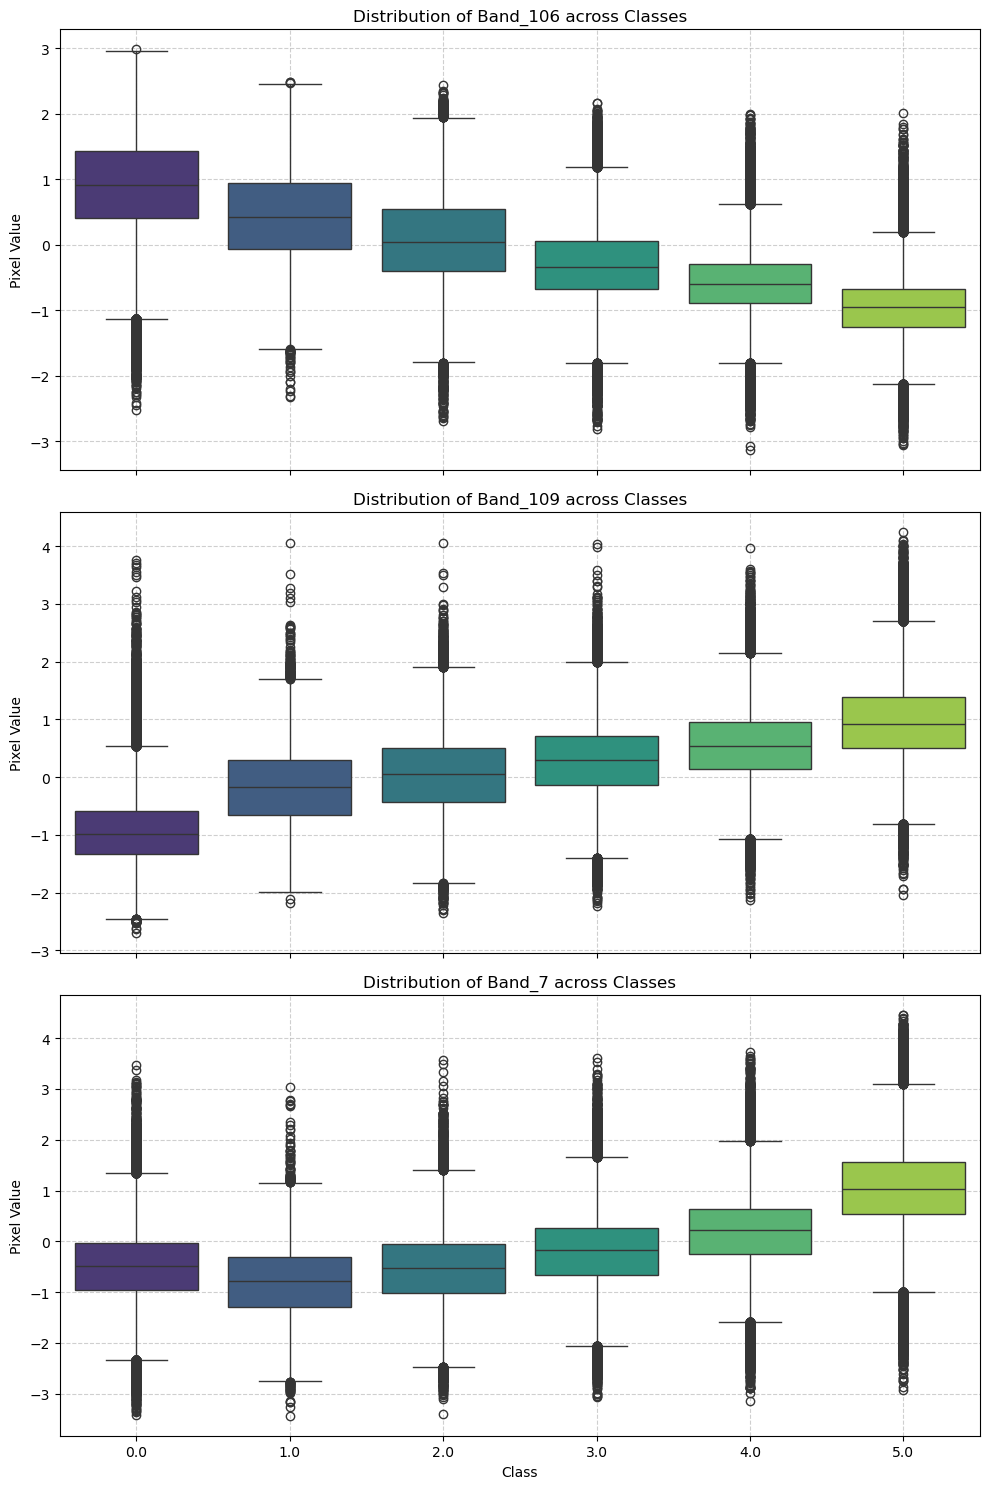

In [7]:
# 1. Define the Plotting Function
def plot_component_boxplots(df, component_ids):
    """
    Renders boxplots for specified components across classes.
    """
    n = len(component_ids)
    fig, axes = plt.subplots(n, 1, figsize=(10, 5 * n), sharex=True)
    if n == 1: axes = [axes]
        
    for i, comp_id in enumerate(component_ids):
        # We ensure the plot uses the 'Class' column in df_combined
        sns.boxplot(data=df, x='Class', y=comp_id, ax=axes[i], palette="viridis")
        axes[i].set_title(f'Distribution of {comp_id} across Classes')
        axes[i].set_ylabel('Pixel Value')
        axes[i].grid(True, linestyle='--', alpha=0.6)
        
    plt.tight_layout()
    plt.show()

# 2. Load Ranking Data and Select Top Bands
# This path must match where you saved your component_ranking_cohen_d.csv
ranking_path = r"C:\Users\user\OneDrive - Politecnico di Milano\File di Daniele Oxoli - test_embeddings\outputs\component_ranking_cohen_d.csv"
df_ranking = pd.read_csv(ranking_path, index_col=0)

# Select the top 3 bands with the highest separability score
top_bands = df_ranking.head(3).index.tolist()

# 3. Execute the Plotting Function
print(f"Plotting the distributions for the top bands: {top_bands}")
plot_component_boxplots(df_combined, top_bands)

### STEP 3d: Geometric Discriminability via Cosine Similarity
This module quantifies the uniqueness of each embedding component by treating class-wise means as geometric vectors. We evaluate how "discriminative" a component is by measuring its angular deviation from a non-discriminative reference vector.
#### 1. Theoretical Basis
Each embedding component ($j$) is represented by a 6-dimensional Component Profile Vector ($A$), containing the mean values for classes 0 through 5:
$$A = [\mu_{j,0}, \mu_{j,1}, \mu_{j,2}, \mu_{j,3}, \mu_{j,4}, \mu_{j,5}]$$
We compare this against a non-discriminative reference vector ($B$), defined as a flat response ($B = [1, 1, 1, 1, 1, 1]$).
The Metrics
1. Cosine Similarity: Measures the orientation between vectors.$$\text{similarity} = \frac{A \cdot B}{||A|| \cdot ||B||}$$
2. Angular Distance: Converts the similarity into a proper distance metric, mapping values to a range of $[0, 1]$, where $0$ indicates a perfectly flat (non-discriminative) response and $1$ indicates maximal distinctness.
$$\text{cos ranking d} = \frac{\arccos(\text{similarity})}{\pi}$$

#### 2. Interpretation of Results
The resulting cosine_ranking.csv provides a geometric ranking of embedding components:
- High Angular Distance ($\approx 1$): Indicates a component with a highly distinct profile across the imperviousness classes. These are your most informative features.
- Low Angular Distance ($\approx 0$): Indicates a "flat" component that does not provide meaningful separation between classes.

In [6]:
# --- 1. LOAD THE DATA ---
# This path should be the same as the summary statistics file generated in Step 3a
#from numpy import cos


input_stats_path = r"C:\Users\user\OneDrive - Politecnico di Milano\File di Daniele Oxoli - test_embeddings\outputs\summary_stats_tab.csv"
df_stats = pd.read_csv(input_stats_path, index_col=0)

# --- 2. PREPARE VECTORS ---
# Select only the mean columns (mean_0 to mean_5)
mean_cols = [f'mean_{i}' for i in range(6)]
A = df_stats[mean_cols].values  # Shape (Num_Bands, 6)

# Define the "non-discriminative" reference vector B (all ones)
B = np.ones(6)

# --- 3. COMPUTE COSINE SIMILARITY ---
# Formula: (A . B) / (||A|| * ||B||)
dot_product = np.dot(A, B)
norm_A = np.linalg.norm(A, axis=1)
norm_B = np.linalg.norm(B) # This is sqrt(6) ≈ 2.449

# Calculate Cosine Similarity
# We add a tiny epsilon to avoid division by zero if norm_A is 0
cosine_similarity = dot_product / (norm_A * norm_B + 1e-10)

# Clip values to [-1, 1] to prevent floating point errors during arccos
cosine_similarity = np.clip(cosine_similarity, -1.0, 1.0)

# --- 4. COMPUTE ANGULAR DISTANCE ---
# Formula: arccos(similarity) / pi
# This results in values between 0 (identical to reference) and 1 (opposite)
#angular_distance 
cosinerankingd = np.arccos(cosine_similarity) / np.pi

# --- 5. SAVE AND RANK ---
df_stats['cosine_similarity'] = cosine_similarity
df_stats['cosinerankingd'] = cosinerankingd

# Sort by angular distance (Higher distance = further from "flat/non-discriminative")
df_ranking_cosine = df_stats[['cosine_similarity', 'cosinerankingd']].sort_values(
    by='cosinerankingd', 
    ascending=False
)

# Save the output
output_path = r"C:\Users\user\OneDrive - Politecnico di Milano\File di Daniele Oxoli - test_embeddings\outputs\cosine_ranking1.csv"
df_ranking_cosine.to_csv(output_path)

print("-" * 30)
print(f"Cosine Similarity analysis complete!")
print(f"Saved to: {output_path}")
print("\nPreview of top 5 discriminative bands (based on angular distance):")
print(df_ranking_cosine.head(5).to_string())
print("-" * 60)

------------------------------
Cosine Similarity analysis complete!
Saved to: C:\Users\user\OneDrive - Politecnico di Milano\File di Daniele Oxoli - test_embeddings\outputs\cosine_ranking1.csv

Preview of top 5 discriminative bands (based on angular distance):
          cosine_similarity  cosinerankingd
Band_80           -0.547637        0.684473
Band_82           -0.537623        0.680678
Band_6            -0.513864        0.671786
Band_103          -0.506666        0.669122
Band_19           -0.504416        0.668292
------------------------------------------------------------
